### This project aims to classify if a video reported is an actual claim or an opinion.

The purpose of this project is to mitigate misinformation spread via social media.

The project follows a workflow called PACE (Plan Analyze Construct Evaluate). The stages in the project may be iterative depending on the findigs throughout the process.

### PLAN

The following questions are to be considered in this phase :
1. What are we being asked to do as a data professional?
2. What metric should be used?
3. How should we proceed?

**What are we being asked to do?**

Ans. Predictive modeling using business insights.
TikTok users can report videos that they believe violate the platform's terms of service. Because there are millions of TikTok videos created and viewed every day, this means that many videos get reported&mdash;too many to be individually reviewed by a human moderator.

Analysis indicates that when authors do violate the terms of service, they're much more likely to be presenting a claim than an opinion. Therefore, it is useful to be able to determine which videos make claims and which videos are opinions.

TikTok wants to build a machine learning model to help identify claims and opinions. Videos that are labeled opinions will be less likely to go on to be reviewed by a human moderator. Videos that are labeled as claims will be further sorted by a downstream process to determine whether they should get prioritized for review. For example, perhaps videos that are classified as claims would then be ranked by how many times they were reported, then the top x% would be reviewed by a human each day.

A machine learning model would greatly assist in the effort to present human moderators with videos that are most likely to be in violation of TikTok's terms of service.

**What metric should be used?**

Ans. Confusion matrix can be used to evaluate TP,FP,TN,FN.



In [ ]:
pip install xgboost

In [ ]:
#IMPORT LIBRARIES

import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, accuracy_score, precision_score, \
recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from xgboost import plot_importance

In [ ]:
df = pd.read_csv('tiktok_dataset.csv')
df.head(10)

,#,claim_status,video_id,video_duration_sec,video_transcription_text,verified_status,author_ban_status,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count
0,1,claim,7017666017,59,someone shared with me that drone deliveries a...,not verified,under review,343296.0,19425.0,241.0,1.0,0.0
1,2,claim,4014381136,32,someone shared with me that there are more mic...,not verified,active,140877.0,77355.0,19034.0,1161.0,684.0
2,3,claim,9859838091,31,someone shared with me that american industria...,not verified,active,902185.0,97690.0,2858.0,833.0,329.0
3,4,claim,1866847991,25,someone shared with me that the metro of st. p...,not verified,active,437506.0,239954.0,34812.0,1234.0,584.0
4,5,claim,7105231098,19,someone shared with me that the number of busi...,not verified,active,56167.0,34987.0,4110.0,547.0,152.0
5,6,claim,8972200955,35,someone shared with me that gross domestic pro...,not verified,under review,336647.0,175546.0,62303.0,4293.0,1857.0
6,7,claim,4958886992,16,someone shared with me that elvis presley has ...,not verified,active,750345.0,486192.0,193911.0,8616.0,5446.0
7,8,claim,2270982263,41,someone shared with me that the best selling s...,not verified,active,547532.0,1072.0,50.0,22.0,11.0
8,9,claim,5235769692,50,someone shared with me that about half of the ...,not verified,active,24819.0,10160.0,1050.0,53.0,27.0
9,10,claim,4660861094,45,someone shared with me that it would take a 50...,verified,active,931587.0,171051.0,67739.0,4104.0,2540.0


### ANALYZE PHASE
This phase requires us to analyze the dataset, it's limitations such as duplicates, missing values and deal with them. It's also necessary to check descriptive statistics to ensure consistency.

In [ ]:
df.shape

(19382, 12)

19K Rows, 12 Features

In [ ]:
df.describe()

,#,video_id,video_duration_sec,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count
count,19382.000000,1.938200e+04,19382.000000,19084.000000,19084.000000,19084.000000,19084.000000,19084.000000
mean,9691.500000,5.627454e+09,32.421732,254708.558688,84304.636030,16735.248323,1049.429627,349.312146
std,5595.245794,2.536440e+09,16.229967,322893.280814,133420.546814,32036.174350,2004.299894,799.638865
min,1.000000,1.234959e+09,5.000000,20.000000,0.000000,0.000000,0.000000,0.000000
25%,4846.250000,3.430417e+09,18.000000,4942.500000,810.750000,115.000000,7.000000,1.000000
50%,9691.500000,5.618664e+09,32.000000,9954.500000,3403.500000,717.000000,46.000000,9.000000
75%,14536.750000,7.843960e+09,47.000000,504327.000000,125020.000000,18222.000000,1156.250000,292.000000
max,19382.000000,9.999873e+09,60.000000,999817.000000,657830.000000,256130.000000,14994.000000,9599.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19382 entries, 0 to 19381
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   #                         19382 non-null  int64  
 1   claim_status              19084 non-null  object 
 2   video_id                  19382 non-null  int64  
 3   video_duration_sec        19382 non-null  int64  
 4   video_transcription_text  19084 non-null  object 
 5   verified_status           19382 non-null  object 
 6   author_ban_status         19382 non-null  object 
 7   video_view_count          19084 non-null  float64
 8   video_like_count          19084 non-null  float64
 9   video_share_count         19084 non-null  float64
 10  video_download_count      19084 non-null  float64
 11  video_comment_count       19084 non-null  float64
dtypes: float64(5), int64(3), object(4)
memory usage: 1.8+ MB


In [ ]:
df.isna().sum()

,0
#,0
claim_status,298
video_id,0
video_duration_sec,0
video_transcription_text,298
verified_status,0
author_ban_status,0
video_view_count,298
video_like_count,298
video_share_count,298


Claim status seems to be missing making the rows pointless.


In [ ]:
df = df.dropna(axis=0)

In [ ]:
#check duplicates

df.duplicated().sum()

np.int64(0)

We have no duplicates in this dataset.

In [ ]:
#check class balance

df['claim_status'].value_counts(normalize=True)*100

,proportion
claim_status,
claim,50.345839
opinion,49.654161


Equal distribution of classes. The variable is balanced.


### CONSTRUCT PHASE

This phase involves building features that will help our predictor variable.


**Feature Engineering**

In [ ]:
#regression and classifiers need numbers in their dataset. We transform everything that is not a number to a number.
#transform text description to its length

df['trans_length'] = df['video_transcription_text'].str.len()

In [ ]:
df.head()

,#,claim_status,video_id,video_duration_sec,video_transcription_text,verified_status,author_ban_status,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count,trans_length
0,1,claim,7017666017,59,someone shared with me that drone deliveries a...,not verified,under review,343296.0,19425.0,241.0,1.0,0.0,97
1,2,claim,4014381136,32,someone shared with me that there are more mic...,not verified,active,140877.0,77355.0,19034.0,1161.0,684.0,107
2,3,claim,9859838091,31,someone shared with me that american industria...,not verified,active,902185.0,97690.0,2858.0,833.0,329.0,137
3,4,claim,1866847991,25,someone shared with me that the metro of st. p...,not verified,active,437506.0,239954.0,34812.0,1234.0,584.0,131
4,5,claim,7105231098,19,someone shared with me that the number of busi...,not verified,active,56167.0,34987.0,4110.0,547.0,152.0,128


In [ ]:
#lets analyze the text length
df[['claim_status','trans_length']].groupby('claim_status').mean()

,trans_length
claim_status,
claim,95.376978
opinion,82.722562


The average for claims is higher than the average for opinions. Might be worth a check

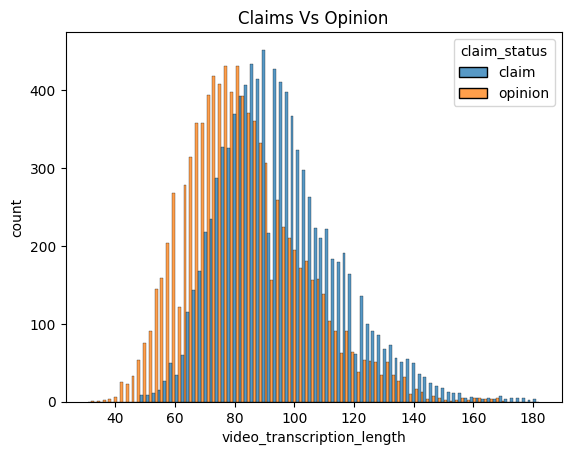

In [ ]:
#visualize

sns.histplot(data=df, stat='count',multiple='dodge',x='trans_length',hue='claim_status',legend=True,element='bars')
plt.xlabel('video_transcription_length')
plt.ylabel('count')
plt.title('Claims Vs Opinion')
plt.show()

Some parts of the opinion curve overlap with claims. While there are some lengths that guarantee that a text belongs to either a claim status or opinion

**Feature selection and transformation**

In [ ]:
#encode categorical variables and target variable
X= df.copy()
X['claim_status'] = X['claim_status'].map({'claim':1,'opinion':0})

X= X.drop(columns=['#','video_id','video_transcription_text'])

In [ ]:
#dummy encode categorical values

X = pd.get_dummies(X, columns=['verified_status','author_ban_status'],drop_first='True')
X.head()

,claim_status,video_duration_sec,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count,trans_length,verified_status_verified,author_ban_status_banned,author_ban_status_under review
0,1,59,343296.0,19425.0,241.0,1.0,0.0,97,False,False,True
1,1,32,140877.0,77355.0,19034.0,1161.0,684.0,107,False,False,False
2,1,31,902185.0,97690.0,2858.0,833.0,329.0,137,False,False,False
3,1,25,437506.0,239954.0,34812.0,1234.0,584.0,131,False,False,False
4,1,19,56167.0,34987.0,4110.0,547.0,152.0,128,False,False,False


In [ ]:
#Split the dataset

y= X.claim_status
X = X.drop(['claim_status'],axis=1)

In [ ]:
# train and test data split

X_tr, X_test, y_tr, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(X_tr, y_tr, test_size=0.25, random_state=0)

In [ ]:
X_train.shape, X_val.shape, X_test.shape, y_train.shape, y_val.shape, y_test.shape

((11450, 10), (3817, 10), (3817, 10), (11450,), (3817,), (3817,))

**Build Model**

**The first classification model that we will build is the RandomForestClassifier**


In [ ]:
rf = RandomForestClassifier(random_state=0)

cv_params = {'max_depth':[5,7,None],
            'max_features':[0.3,0.6],
            'max_samples':[0.7],
            'min_samples_leaf': [1,2],
             'min_samples_split': [2,3],
             'n_estimators': [75,100,200]}



In [ ]:
scoring = ['accuracy', 'precision', 'recall', 'f1']

In [ ]:
rf_cv = GridSearchCV(rf,cv_params,scoring=scoring,cv=5,refit='recall')

In [ ]:
rf_cv

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=0),
             param_grid={'max_depth': [5, 7, None], 'max_features': [0.3, 0.6],
                         'max_samples': [0.7], 'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 3],
                         'n_estimators': [75, 100, 200]},
             refit='recall', scoring=['accuracy', 'precision', 'recall', 'f1'])

In [ ]:
rf_cv.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=0),
             param_grid={'max_depth': [5, 7, None], 'max_features': [0.3, 0.6],
                         'max_samples': [0.7], 'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 3],
                         'n_estimators': [75, 100, 200]},
             refit='recall', scoring=['accuracy', 'precision', 'recall', 'f1'])

In [ ]:
rf_cv.best_score_ * 100

np.float64(99.08534395531852)

Our first model iteration has a best score of 99%. This is good and there are less chances of a data leakage, as there are no variables that directly implicate the predictor variable.

Let us check the precision score to make sure that the model is not labelling every case to be a claim.

In [ ]:
rf_cv.cv_results_['mean_test_precision'][rf_cv.best_index_]

np.float64(0.9994785483051682)

This proves that the model works fine, it is able to predict claims accurately.

# Build XGBoost model

In [ ]:
xg = XGBClassifier(objective="binary:logistic", random_state=0)

In [ ]:
#create parameters

cv_params = {'max_depth': [4,8,12],
             'min_child_weight': [3, 5],
             'learning_rate': [0.01, 0.1],
             'n_estimators': [300, 500]
             }

In [ ]:
xg_cv = GridSearchCV(xg,cv_params,scoring=scoring,cv=5,refit='recall')

In [ ]:
xg_cv.fit(X_train,y_train)

GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, feature_weights=None,
                                     gamma=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=Non...
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             param_grid={'learning_rate': [0.01, 0.1], 'max_depth': [4, 8, 12],
                         'min_child_weight': [3, 5],
                         'n_estimators': [300, 500]},
             refit='recall', scoring=['accuracy', 'precision', 'recall', 'f1'])

In [ ]:
xg_cv.best_score_ * 100

np.float64(98.98176171763818)

The model gives a best score of 98%.

In [ ]:
xg_cv.cv_results_['mean_test_precision'][rf_cv.best_index_]

np.float64(0.998780172085586)

In [ ]:
xg_cv.best_params_

{'learning_rate': 0.1,
 'max_depth': 4,
 'min_child_weight': 5,
 'n_estimators': 300}

# EVALUATE PHASE


In this phase, we evaluate both the models against the validation data.

In [ ]:
y_pred= rf_cv.best_estimator_.predict(X_val)

In [ ]:
#Confusion matrix to check the predicted values against the validation data

cf = confusion_matrix(y_val,y_pred)
cf

array([[1887,    5],
       [  20, 1905]])

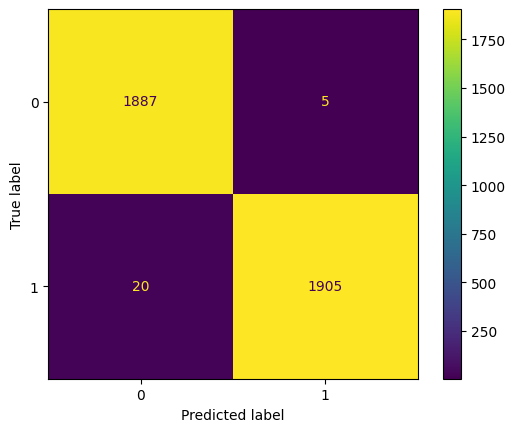

In [ ]:
log_disp = ConfusionMatrixDisplay(confusion_matrix=cf,display_labels=rf_cv.classes_)
log_disp.plot()

This is a confusion matrix for Random Forest.

The top left row showcase true negatives i.e the number of opinions the model rightfully classified.

The top right row displays the false positives i.e the number of opinions the model wrongfully predicted.

The bottom left row displays the false negatives i.e the number of claims the model rightfully classified as opinions.

The bottom right displays the true positives i.e the number of claims the model rightfully classified.


In [ ]:
target_labels = ['opinion','claim']
print(classification_report(y_val,y_pred,target_names=target_labels))

              precision    recall  f1-score   support

     opinion       0.99      1.00      0.99      1892
       claim       1.00      0.99      0.99      1925

    accuracy                           0.99      3817
   macro avg       0.99      0.99      0.99      3817
weighted avg       0.99      0.99      0.99      3817



In [ ]:
#Evalution of XG-Boost

y_pred = xg_cv.best_estimator_.predict(X_val)

In [ ]:
cf = confusion_matrix(y_val,y_pred)
cf

array([[1888,    4],
       [  22, 1903]])

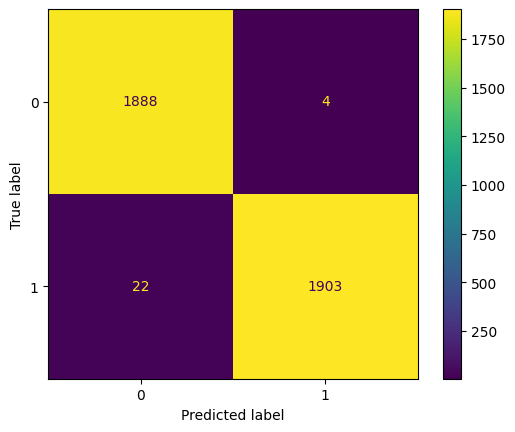

In [ ]:
log_disp = ConfusionMatrixDisplay(confusion_matrix=cf,display_labels=xg_cv.classes_)
log_disp.plot()

This is a confusion matrix for XGBoost.

The top left row showcase true negatives i.e the number of opinions the model rightfully classified.

The top right row displays the false positives i.e the number of opinions the model wrongfully predicted.

The bottom left row displays the false negatives i.e the number of claims the model rightfully classified as opinions.

The bottom right displays the true positives i.e the number of claims the model rightfully classified.


In [ ]:
#compare both the models using a report

target_labels = ['claim','opinion']
print(classification_report(y_val,y_pred,target_names=target_labels))

              precision    recall  f1-score   support

       claim       0.99      1.00      0.99      1892
     opinion       1.00      0.99      0.99      1925

    accuracy                           0.99      3817
   macro avg       0.99      0.99      0.99      3817
weighted avg       0.99      0.99      0.99      3817



**We can conclude that Random Forest is the best model here as it has the least amount of values there predicted to be wrong (5).**

## Train champion model

In [ ]:
y_pred = rf_cv.best_estimator_.predict(X_test)


In [ ]:
cf= confusion_matrix(y_test,y_pred)
cf

array([[1925,    3],
       [  16, 1873]])

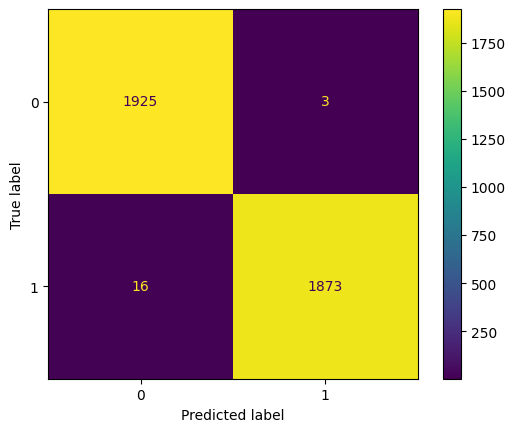

In [ ]:
log_disp = ConfusionMatrixDisplay(cf,display_labels=rf_cv.classes_)
log_disp.plot()

The master model here states these findings via the confusion matrix :

1925 claims were rightfully classified

3 of the claims that got identified were wrong.

16 opinions that were classified were incorrect.

1873 classified opinions were correct.

In [ ]:
#check model performance

target_labels = ['claim','opinion']
print(classification_report(y_test,y_pred,target_names=target_labels))

              precision    recall  f1-score   support

       claim       0.99      1.00      1.00      1928
     opinion       1.00      0.99      0.99      1889

    accuracy                           1.00      3817
   macro avg       1.00      0.99      1.00      3817
weighted avg       1.00      1.00      1.00      3817



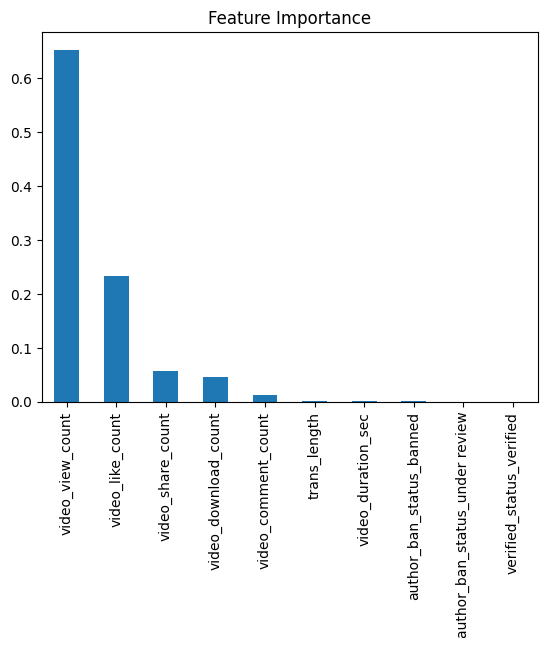

In [ ]:
#which were the important features for this model.
importances = rf_cv.best_estimator_.feature_importances_

rf_imp = pd.Series(importances, index=X_train.columns).sort_values(ascending=False)

rf_imp.plot.bar()
plt.title('Feature Importance')
plt.show()

The model states that a videos views, likes, share, download and comment count were key in predicting if a case was claimed or an opinion.



In [ ]:
y_pred = pd.Series(y_pred)
y_pred.value_counts(normalize='True')*100

,proportion
0,50.851454
1,49.148546


##CONDUCT A HYPOTHESIS TEST

Let's check how the features verified_status and video_views_count relate to each other.

Are they related to each other?


In [ ]:
import pandas as pd
import numpy as np
from scipy import stats

import seaborn as sns

In [ ]:
df = pd.read_csv('tiktok_dataset.csv')

df.head(10)

,#,claim_status,video_id,video_duration_sec,video_transcription_text,verified_status,author_ban_status,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count
0,1,claim,7017666017,59,someone shared with me that drone deliveries a...,not verified,under review,343296.0,19425.0,241.0,1.0,0.0
1,2,claim,4014381136,32,someone shared with me that there are more mic...,not verified,active,140877.0,77355.0,19034.0,1161.0,684.0
2,3,claim,9859838091,31,someone shared with me that american industria...,not verified,active,902185.0,97690.0,2858.0,833.0,329.0
3,4,claim,1866847991,25,someone shared with me that the metro of st. p...,not verified,active,437506.0,239954.0,34812.0,1234.0,584.0
4,5,claim,7105231098,19,someone shared with me that the number of busi...,not verified,active,56167.0,34987.0,4110.0,547.0,152.0
5,6,claim,8972200955,35,someone shared with me that gross domestic pro...,not verified,under review,336647.0,175546.0,62303.0,4293.0,1857.0
6,7,claim,4958886992,16,someone shared with me that elvis presley has ...,not verified,active,750345.0,486192.0,193911.0,8616.0,5446.0
7,8,claim,2270982263,41,someone shared with me that the best selling s...,not verified,active,547532.0,1072.0,50.0,22.0,11.0
8,9,claim,5235769692,50,someone shared with me that about half of the ...,not verified,active,24819.0,10160.0,1050.0,53.0,27.0
9,10,claim,4660861094,45,someone shared with me that it would take a 50...,verified,active,931587.0,171051.0,67739.0,4104.0,2540.0


In [ ]:
#drop the missing values

df = df.dropna(axis=0)

In [ ]:
verif = df.groupby('verified_status')['video_view_count'].mean()
verif

,video_view_count
verified_status,
not verified,265663.785339
verified,91439.164167


The not verified accounts have a higher video view count than verified ones. Let's conduct a ttest to confirm this.

In order to do so, we follow the following steps :

1. State null hypothesis and alternative hypothesis.

2. Choose a significance level

3. Find the p-value

4. Reject or fail to reject null hypothesis.

The null hypothesis: There is no difference between the two means.

The alternative hypothesis: There is a difference.

Significance level : 5%

In [ ]:
not_verified = df[df['verified_status']=='not verified']['video_view_count']
verified = df[df['verified_status']=='verified']['video_view_count']


In [ ]:
stats.ttest_ind(a=not_verified, b=verified, equal_var=False)

TtestResult(statistic=np.float64(25.499441780633777), pvalue=np.float64(2.6088823687177823e-120), df=np.float64(1571.163074387424))

## Conclusion

The p-value is really miniscule for our significance level. Hence, we can reject the null hypothesis.

In [ ]:
#lets find out the relationship of rest of the continuous variables with account verification

not_verified_likes = df[df['verified_status']=='not verified']['video_like_count']
verified_likes = df[df['verified_status']=='verified']['video_like_count']


In [ ]:
test = df.groupby('verified_status')['video_like_count'].mean()
test

,video_like_count
verified_status,
not verified,87925.772422
verified,30337.633333


This suggests that non-verified accounts have more likes on average as compared to verified accounts. Lets confirm this with a ttest

In [ ]:
stats.ttest_ind(a=not_verified_likes, b=verified_likes, equal_var=False)

TtestResult(statistic=np.float64(21.315562151092116), pvalue=np.float64(4.6511316028672245e-89), df=np.float64(1618.4605703060377))

Just like before, the p-value is really small, helping us negate the null hypothesis.

In [ ]:
test1 = df.groupby('verified_status')['video_share_count'].mean()
test1

,video_share_count
verified_status,
not verified,17415.888000
verified,6591.448333


In [ ]:
not_verified_shares = df[df['verified_status']=='not verified']['video_share_count']
verified_shares = df[df['verified_status']=='verified']['video_share_count']

In [ ]:
stats.ttest_ind(a=not_verified_shares, b=verified_shares, equal_var=False)

TtestResult(statistic=np.float64(16.73435284048433), pvalue=np.float64(4.079823421874693e-58), df=np.float64(1623.9175460325248))

In [ ]:
test2 = df.groupby('verified_status')['video_download_count'].mean()
test2

,video_download_count
verified_status,
not verified,1095.814080
verified,358.146667


In [ ]:
not_verified_downloads = df[df['verified_status']=='not verified']['video_download_count']
verified_downloads = df[df['verified_status']=='verified']['video_download_count']

In [ ]:
stats.ttest_ind(a=not_verified_downloads,b=verified_downloads,equal_var=False)

TtestResult(statistic=np.float64(19.277585031563547), pvalue=np.float64(5.216621962283665e-75), df=np.float64(1689.623459375426))

In [ ]:
test3 = df.groupby('verified_status')['video_comment_count'].mean()
test3

,video_comment_count
verified_status,
not verified,363.700514
verified,134.877500


In [ ]:
not_verified_comments = df[df['verified_status']=='not verified']['video_comment_count']
verified_comments = df[df['verified_status']=='verified']['video_comment_count']

In [ ]:
stats.ttest_ind(a=not_verified_comments,b=verified_comments,equal_var=False)

TtestResult(statistic=np.float64(13.530086956287226), pvalue=np.float64(1.5228386305061084e-39), df=np.float64(1577.5262060917944))

Something to note here is that even though the non-verified accounts have a larger mean, the gap between verified and non-verified accounts keeps closing.

In [ ]:
f_df = df.drop(columns=['#','video_id','video_transcription_text','video_duration_sec', 'author_ban_status','claim_status'],axis=1)

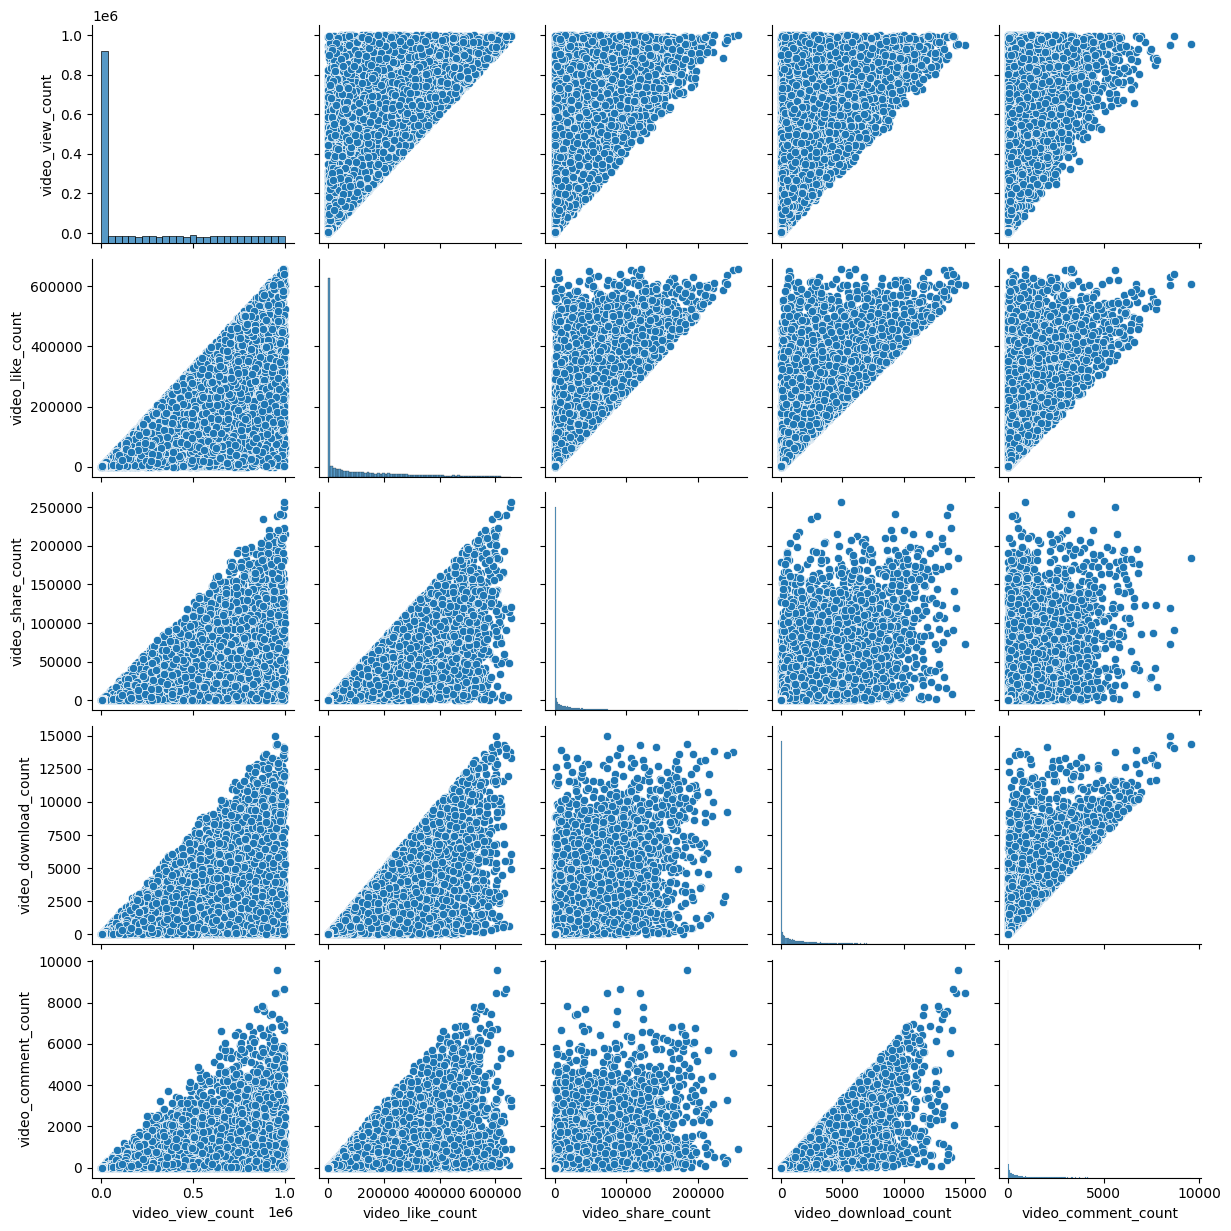

In [ ]:
import seaborn as sns

sns.pairplot(f_df)

In [ ]:
f_df['verified_status'] = f_df['verified_status'].map({'not verified':0,'verified':1})

In [ ]:
f_df['verified_status'].value_counts()

,count
verified_status,
0,17884
1,1200


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [ ]:
#Split into X and y
X = f_df.drop(columns=['verified_status'],axis=1)
y= f_df['verified_status']

In [ ]:
#Train and test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state= 1000,stratify=y)

In [ ]:
X_tr , X_val , y_tr, y_val = train_test_split(X_train,y_train, test_size=0.2,random_state=1000,stratify=y_train)

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
pipe = Pipeline([("scaler",StandardScaler()),("lr",LogisticRegression( solver="lbfgs",
        max_iter=2000, class_weight='balanced'))])
pipe.fit(X_tr,y_tr)

Pipeline(steps=[('scaler', StandardScaler()),
                ('lr',
                 LogisticRegression(class_weight='balanced', max_iter=2000))])

In [ ]:
res=pipe.predict(X_test)

In [ ]:
res


array([1, 1, 1, ..., 1, 0, 1])

In [ ]:
np.unique(res,return_counts=True)

(array([0, 1]), array([1621, 2196]))